# Exploration and processing

The previous notebook turned a pile of files into a couple of master files.
Those can be shared with the whole team, and they are the starting point for
any actual work. This notebook is that work: select, look, process.

In [1]:
import numpy as np

import xdas as xd

In [2]:
da = xd.open("outputs/singlecable.nc")
da

<xdas.DataArray (time: 37500, distance: 10000)>
VirtualSource: 715.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:20:01.000 to 2023-11-03T12:30:00.984

## Selection

`sel` selects by coordinate value, `isel` by index. They compose, so
"4000 samples starting at that instant" reads directly:

In [3]:
da = da.sel(time=slice("2023-11-03T12:26:40", None))  # everything after
da = da.isel(time=slice(None, 4000))  # then the first 4000 samples
da.to_netcdf("outputs/event.nc")  # keep it for the next notebook
da

<xdas.DataArray (time: 4000, distance: 10000)>
VirtualSource: 76.3MB (int16)
Coordinates:
  * distance (distance): 0.000 to 153179.709
  * time (time): 2023-11-03T12:26:40.008 to 2023-11-03T12:27:43.992

## Visualization

A data array carries its own coordinates, so it knows how to draw itself:

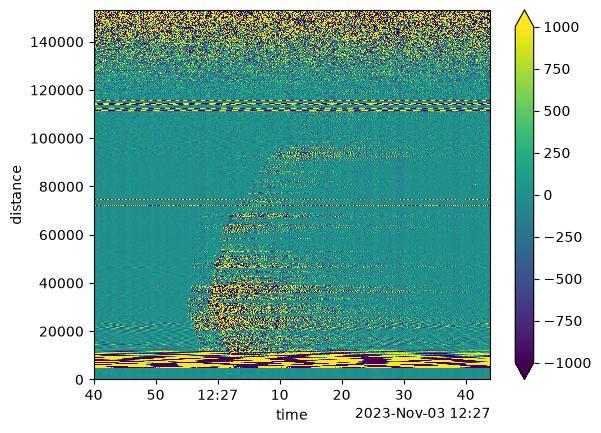

In [4]:
da.plot(x="time", vmin=-1000, vmax=1000)

## Basic processing

Most numpy functions work directly on a data array and keep the metadata.
Arithmetic works too, with Xdas checking that dimensions and coordinates
agree:

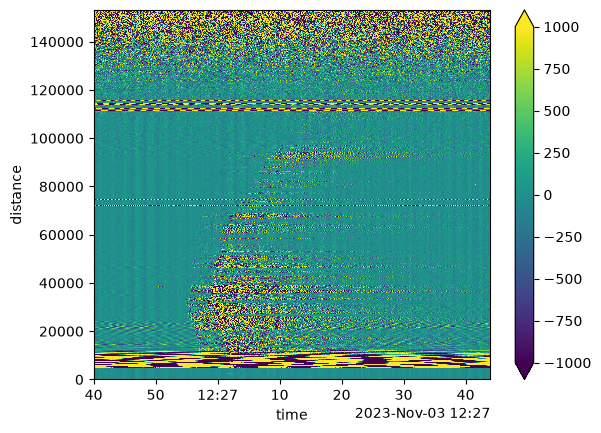

In [5]:
squared = np.square(da)
mean = xd.mean(da, "time")
std = da.std("distance")

common_mode_removal = da - da.mean("distance")
common_mode_removal.plot(x="time", vmin=-1000, vmax=1000)

## Processing in physical units

Xdas wraps a large part of `scipy.signal`, but the top-level functions do
not take the parameters of the SciPy routine underneath — a number of output
samples, a decimation factor, a normalized frequency. They take the
quantities of the measurement itself: a rate in Hz, a corner frequency in Hz,
a window length in seconds or metres.

The point is that such a parameter keeps its meaning when the sampling rate
changes. The same pipeline can then be handed a different acquisition, or a
chunk that has already been resampled, and still do what you meant.

Filtering asks for corner frequencies in Hz — `(low, high)`, with `None`
opening one end:

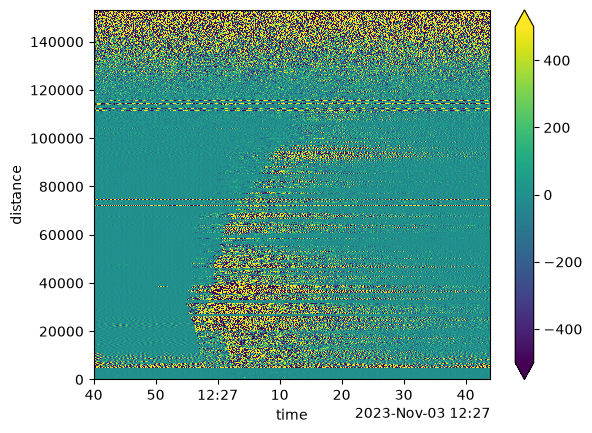

In [6]:
filtered = xd.filter(da, (1.0, 10.0), dim="time")  # bandpass 1-10 Hz
filtered.plot(x="time", vmin=-500, vmax=500)

Decimating asks for the sampling rate you want, in Hz along time and in 1/m
along distance. This cable is sampled at 62.5 Hz and every 15.32 m:

In [7]:
dx = xd.get_sampling_interval(da, "distance")
print(f"{1 / xd.get_sampling_interval(da, 'time'):.1f} Hz, one channel every {dx:.2f} m")

62.5 Hz, one channel every 15.32 m


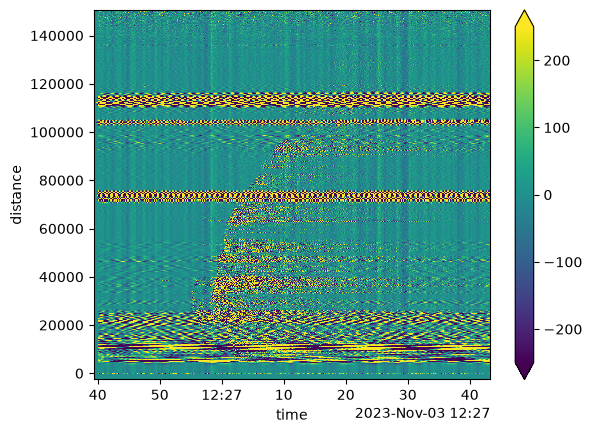

In [8]:
decimated = xd.decimate(da, 1 / (16 * dx), dim="distance")  # one channel per ~245 m
decimated = xd.decimate(decimated, 15.625, dim="time")  # 62.5 Hz -> 15.625 Hz

decimated.plot(x="time", vmin=-250, vmax=250)

```{note}
`decimate` only accepts integer ratios, because that is all an anti-alias
filter plus a stride can do. For anything else — 62.5 Hz to 100 Hz, say —
use `xd.resample`, which polyphase-filters its way to any target rate.
```

## An FK diagram

Nothing forces a data array to stay in time and distance. Here the two axes
are transformed and renamed on the way:

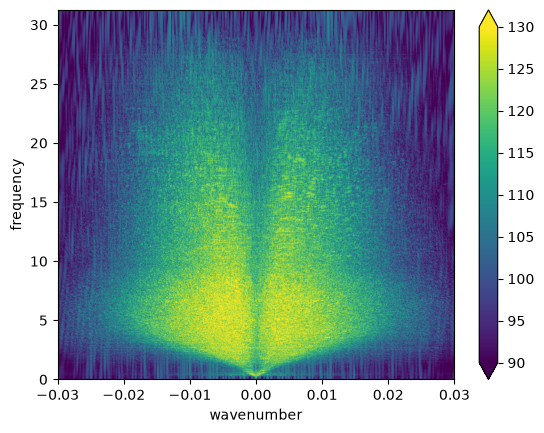

In [9]:
fk = da.sel(distance=slice(30_000, 70_000))
fk = xd.taper(fk, dim="distance")
fk = xd.taper(fk, dim="time")
fk = xd.fft.rfft(fk, dim={"time": "frequency"})  # rename "time" -> "frequency"
fk = xd.fft.fft(fk, dim={"distance": "wavenumber"})  # and "distance" -> "wavenumber"
fk = 20 * np.log10(np.abs(fk))

fk.plot(interpolation="antialiased", vmin=90, vmax=130, xlim=(-0.03, 0.03))

## From strain rate to displacement

The instrument records strain rate per unit length. Integrating along the
cable gives a deformation, from which a sliding mean is removed to suppress
the very long wavelengths the integration amplifies:

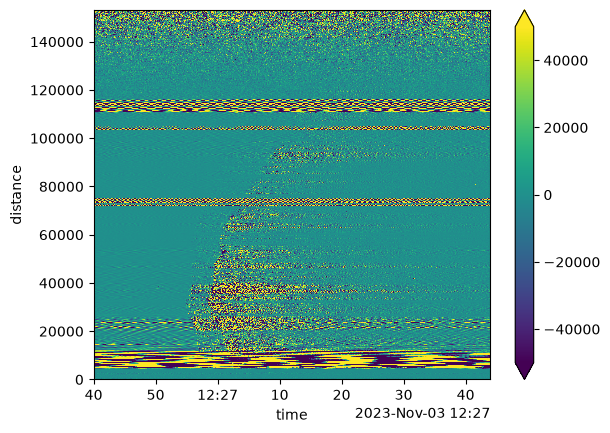

In [10]:
deformation = xd.integrate(da, dim="distance")
displacement = xd.sliding_mean_removal(deformation, wlen=1000.0, dim="distance")

displacement.plot(x="time", yincrease=True, vmin=-50_000, vmax=50_000)

Note that `wlen=1000.0` is a thousand *metres*, because the dimension is
distance. On the time axis the very same call would read seconds.